In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_energy_data.csv")

In [3]:
df.head()

,DateTime,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,...,Zone_3_roll_max_1h,Zone_3_roll_mean_24h,Zone_3_roll_std_24h,Zone_3_roll_min_24h,Zone_3_roll_max_24h,Temp_Humidity_Index,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,...,NaN,NaN,NaN,NaN,NaN,-23.858374,False,False,False,True
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,...,20240.96386,20240.963860,NaN,20240.96386,20240.96386,-24.599243,False,False,False,True
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,...,20240.96386,20186.024100,77.696554,20131.08434,20240.96386,-24.951034,False,False,False,True
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,...,20240.96386,20013.493977,303.839279,19668.43373,20240.96386,-25.795530,False,False,False,True
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,...,20240.96386,19734.939760,609.848625,18899.27711,20240.96386,-26.746187,False,False,False,True


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 52416
Number of columns: 53


In [5]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['DateTime', 'Temperature', 'Humidity', 'Wind_Speed', 'General_Diffuse_Flows', 'Diffuse_Flows', 'Zone_1_Power_Consumption', 'Zone_2_Power_Consumption', 'Zone_3_Power_Consumption', 'Hour', 'Day_of_Week', 'Month', 'Quarter', 'Is_Weekend', 'Is_Peak_Hour', 'Zone_1_lag_1', 'Zone_1_lag_6', 'Zone_1_lag_144', 'Zone_2_lag_1', 'Zone_2_lag_6', 'Zone_2_lag_144', 'Zone_3_lag_1', 'Zone_3_lag_6', 'Zone_3_lag_144', 'Zone_1_roll_mean_1h', 'Zone_1_roll_std_1h', 'Zone_1_roll_min_1h', 'Zone_1_roll_max_1h', 'Zone_1_roll_mean_24h', 'Zone_1_roll_std_24h', 'Zone_1_roll_min_24h', 'Zone_1_roll_max_24h', 'Zone_2_roll_mean_1h', 'Zone_2_roll_std_1h', 'Zone_2_roll_min_1h', 'Zone_2_roll_max_1h', 'Zone_2_roll_mean_24h', 'Zone_2_roll_std_24h', 'Zone_2_roll_min_24h', 'Zone_2_roll_max_24h', 'Zone_3_roll_mean_1h', 'Zone_3_roll_std_1h', 'Zone_3_roll_min_1h', 'Zone_3_roll_max_1h', 'Zone_3_roll_mean_24h', 'Zone_3_roll_std_24h', 'Zone_3_roll_min_24h', 'Zone_3_roll_max_24h', 'Temp_Humidity_Index', 'Sea

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DateTime                  52416 non-null  str    
 1   Temperature               52416 non-null  float64
 2   Humidity                  52416 non-null  float64
 3   Wind_Speed                52416 non-null  float64
 4   General_Diffuse_Flows     52416 non-null  float64
 5   Diffuse_Flows             52416 non-null  float64
 6   Zone_1_Power_Consumption  52416 non-null  float64
 7   Zone_2_Power_Consumption  52416 non-null  float64
 8   Zone_3_Power_Consumption  52416 non-null  float64
 9   Hour                      52416 non-null  int64  
 10  Day_of_Week               52416 non-null  int64  
 11  Month                     52416 non-null  int64  
 12  Quarter                   52416 non-null  int64  
 13  Is_Weekend                52416 non-null  int64  
 14  Is_Peak_Hour     

In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
DateTime                      0
Temperature                   0
Humidity                      0
Wind_Speed                    0
General_Diffuse_Flows         0
Diffuse_Flows                 0
Zone_1_Power_Consumption      0
Zone_2_Power_Consumption      0
Zone_3_Power_Consumption      0
Hour                          0
Day_of_Week                   0
Month                         0
Quarter                       0
Is_Weekend                    0
Is_Peak_Hour                  0
Zone_1_lag_1                  1
Zone_1_lag_6                  6
Zone_1_lag_144              144
Zone_2_lag_1                  1
Zone_2_lag_6                  6
Zone_2_lag_144              144
Zone_3_lag_1                  1
Zone_3_lag_6                  6
Zone_3_lag_144              144
Zone_1_roll_mean_1h           1
Zone_1_roll_std_1h            2
Zone_1_roll_min_1h            1
Zone_1_roll_max_1h            1
Zone_1_roll_mean_24h          1
Zone_1_roll_std_24h           2
Zone_1_ro

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df.describe()

,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Hour,Day_of_Week,...,Zone_2_roll_max_24h,Zone_3_roll_mean_1h,Zone_3_roll_std_1h,Zone_3_roll_min_1h,Zone_3_roll_max_1h,Zone_3_roll_mean_24h,Zone_3_roll_std_24h,Zone_3_roll_min_24h,Zone_3_roll_max_24h,Temp_Humidity_Index
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,...,52415.000000,52415.000000,52414.000000,52415.000000,52415.000000,52415.000000,52414.000000,52415.000000,52415.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.471746,17737.319088,11.500000,3.000000,...,28913.584734,17737.690047,458.099102,17145.986519,18330.188545,17742.181233,4163.269281,10773.948364,25502.837077,16.744079
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.353750,6320.262786,6.922253,2.000019,...,3591.388351,6290.791748,485.939337,6206.476552,6388.732232,4675.272507,919.237725,2796.230543,5526.529685,17.915570
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070,0.000000,0.000000,...,16128.875380,6132.052821,0.000000,5935.174070,6275.150060,10453.581433,77.696554,5935.174070,15195.198080,-39.163665
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630,5.750000,1.000000,...,26239.513680,13127.829039,148.897176,12539.729210,13727.677215,14281.195897,3212.081057,8984.187947,20474.770170,3.572755
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470,11.500000,3.000000,...,28329.483280,16423.132530,299.537967,15974.400000,16863.195980,17407.477017,4281.170068,10617.831330,25943.132530,18.224656
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420,17.250000,5.000000,...,31803.167900,21621.815365,577.258700,20425.104600,22777.916820,18986.317327,4849.345903,11485.090910,28321.476920,30.400693
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,36313.144751,34366.261105,23.000000,6.000000,...,36313.144751,34366.261105,3582.814758,34366.261105,34366.261105,30835.230654,6663.104799,20304.602510,34366.261105,58.529350


In [10]:
# Calculate the total energy demand of all three zones

df["Total_Demand"] = (
    df["Zone_1_Power_Consumption"]
    + df["Zone_2_Power_Consumption"]
    + df["Zone_3_Power_Consumption"]
)

# Display the result
df[[
    "DateTime",
    "Zone_1_Power_Consumption",
    "Zone_2_Power_Consumption",
    "Zone_3_Power_Consumption",
    "Total_Demand"
]].head()

,DateTime,Zone_1_Power_Consumption,Zone_2_Power_Consumption,Zone_3_Power_Consumption,Total_Demand
0,2017-01-01 00:00:00,34055.69620,16128.87538,20240.96386,70425.53544
1,2017-01-01 00:10:00,29814.68354,19375.07599,20131.08434,69320.84387
2,2017-01-01 00:20:00,29128.10127,19006.68693,19668.43373,67803.22193
3,2017-01-01 00:30:00,28228.86076,18361.09422,18899.27711,65489.23209
4,2017-01-01 00:40:00,27335.69620,17872.34043,18442.40964,63650.44627


In [11]:
# Statistical summary of total demand

df["Total_Demand"].describe()

count     52416.000000
mean      71124.761397
std       16877.296239
min       36785.039739
25%       56499.074640
50%       69788.790940
75%       83749.172310
max      122699.906485
Name: Total_Demand, dtype: float64

In [12]:
# Calculate the 90th percentile as the peak demand threshold

peak_threshold = df["Total_Demand"].quantile(0.90)

print("Peak Demand Threshold:", peak_threshold)

Peak Demand Threshold: 94912.14182


In [13]:
# Create the Peak_Demand target column
# 1 = Peak demand
# 0 = Normal demand

df["Peak_Demand"] = (
    df["Total_Demand"] >= peak_threshold
).astype(int)

# Display the first few rows
df[[
    "DateTime",
    "Total_Demand",
    "Peak_Demand"
]].head(20)

,DateTime,Total_Demand,Peak_Demand
0,2017-01-01 00:00:00,70425.53544,0
1,2017-01-01 00:10:00,69320.84387,0
2,2017-01-01 00:20:00,67803.22193,0
3,2017-01-01 00:30:00,65489.23209,0
4,2017-01-01 00:40:00,63650.44627,0
5,2017-01-01 00:50:00,62171.34398,0
6,2017-01-01 01:00:00,60937.36065,0
7,2017-01-01 01:10:00,59566.75124,0
8,2017-01-01 01:20:00,58030.61931,0
9,2017-01-01 01:30:00,57012.92027,0


In [14]:
# Count normal and peak demand records

print("Peak Demand Counts:")
print(df["Peak_Demand"].value_counts())

Peak Demand Counts:
Peak_Demand
0    47174
1     5242
Name: count, dtype: int64


In [ ]:
# Convert DateTime from text to datetime format

df["DateTime"] = pd.to_datetime(df["DateTime"])

# Check the data type

print(df["DateTime"].dtype)

In [15]:
# Calculate percentages

print("Peak Demand Percentages:")
print(df["Peak_Demand"].value_counts(normalize=True) * 100)

Peak Demand Percentages:
Peak_Demand
0    89.999237
1    10.000763
Name: proportion, dtype: float64


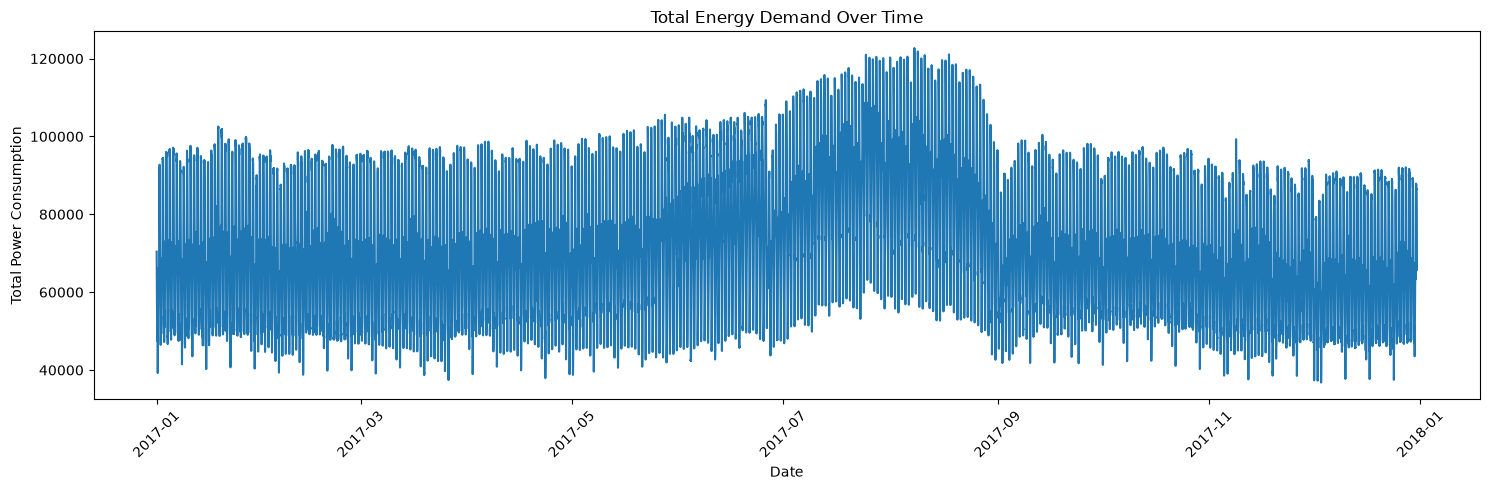

In [17]:
# Plot total energy demand over time

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"]
)

plt.title("Total Energy Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

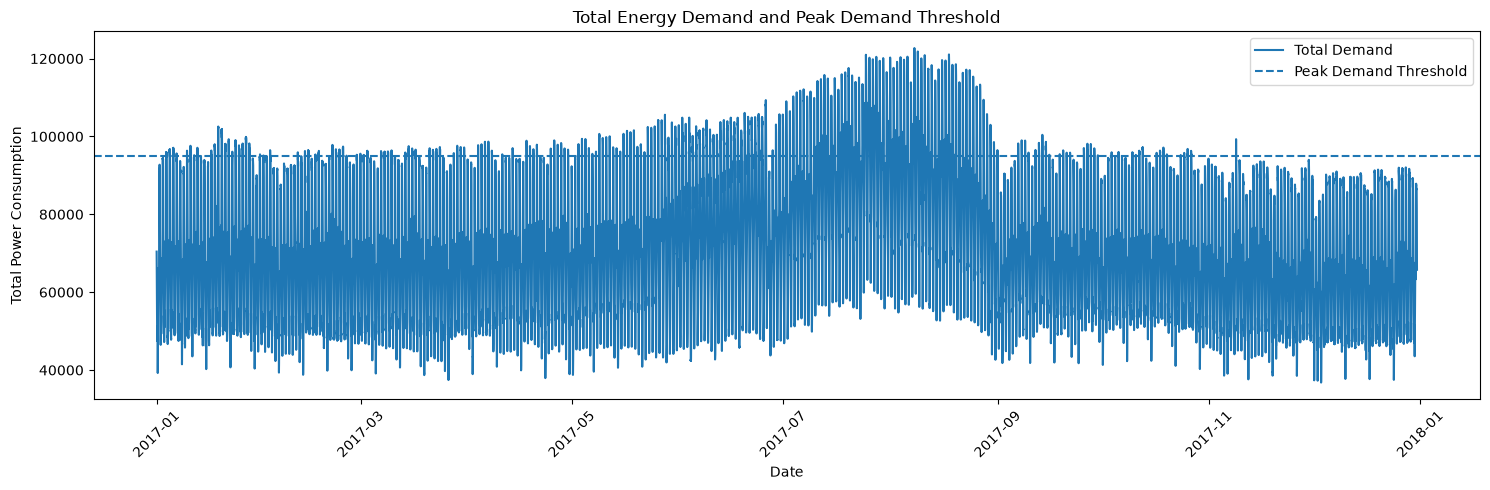

In [18]:
# Plot total demand together with the peak threshold

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"],
    label="Total Demand"
)

plt.axhline(
    y=peak_threshold,
    linestyle="--",
    label="Peak Demand Threshold"
)

plt.title("Total Energy Demand and Peak Demand Threshold")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# Convert DateTime from text to datetime format

df["DateTime"] = pd.to_datetime(df["DateTime"])

# Check the data type

print(df["DateTime"].dtype)

datetime64[us]


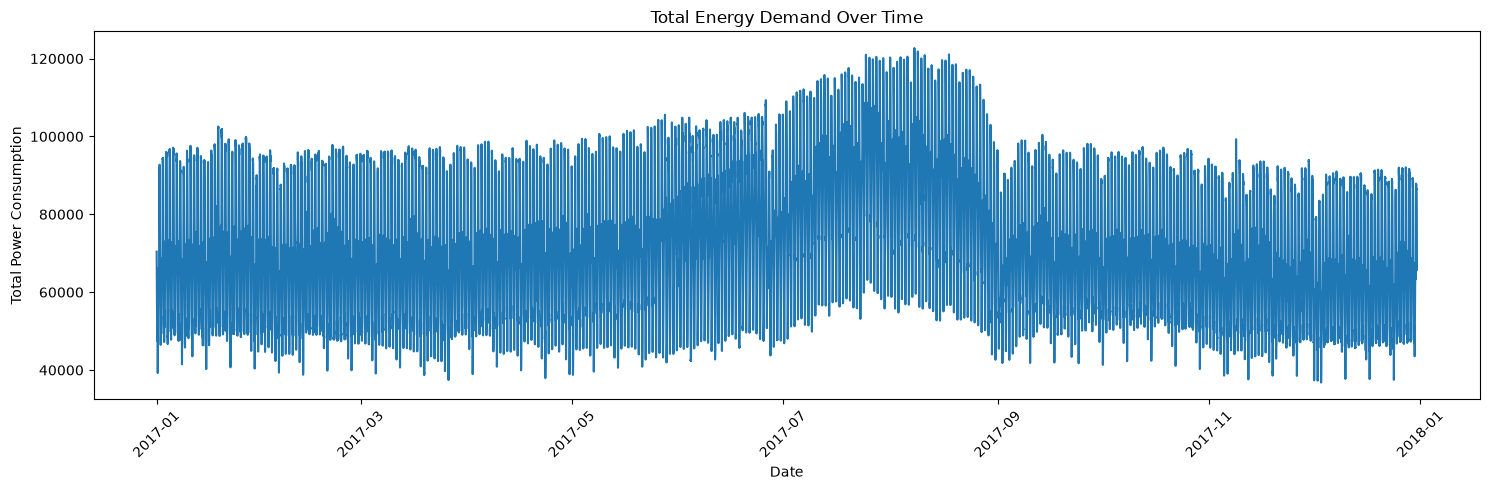

In [20]:
# Plot total energy demand over time

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"]
)

plt.title("Total Energy Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

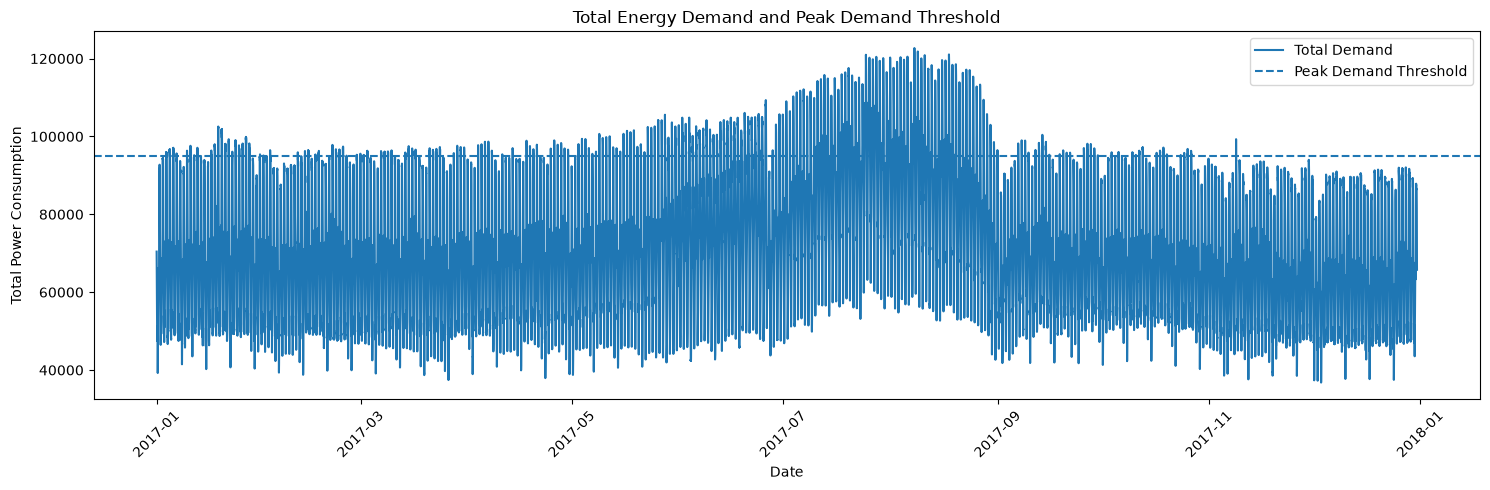

In [21]:
# Plot total demand together with the peak threshold

plt.figure(figsize=(15, 5))

plt.plot(
    df["DateTime"],
    df["Total_Demand"],
    label="Total Demand"
)

plt.axhline(
    y=peak_threshold,
    linestyle="--",
    label="Peak Demand Threshold"
)

plt.title("Total Energy Demand and Peak Demand Threshold")
plt.xlabel("Date")
plt.ylabel("Total Power Consumption")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

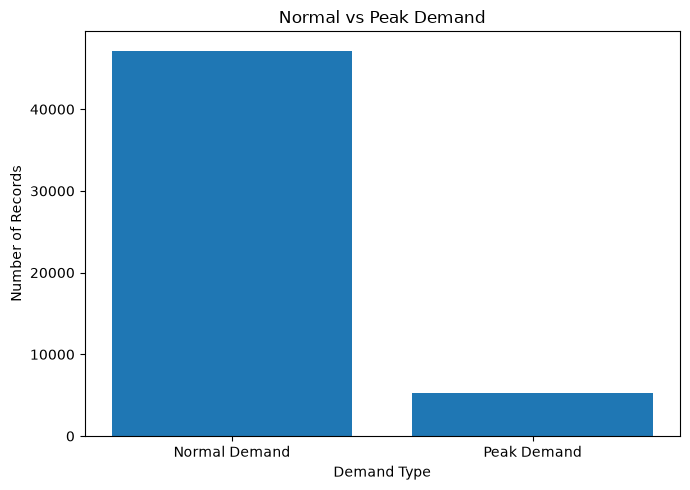

In [22]:
# Count normal and peak demand records

peak_counts = df["Peak_Demand"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal Demand", "Peak Demand"],
    peak_counts.values
)

plt.title("Normal vs Peak Demand")
plt.xlabel("Demand Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()